# Sentiment classification with BERT & PhoBert - Exploiting multi-layer feature extraction

`imdb_reviews` dataset is a large movie review dataset. This dataset is for binary sentiment classification containing a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. All the reviews have either a *positive* or *negative* sentiment.
Reference: http://ai.stanford.edu/~amaas/data/sentiment/

Each data sample contains:
* label (tf.int64)
* text (tf.string)

The notebook exploits multi-layer feature extraction of a BERT model which comprises of several Transformer-encoder blocks. The model I used is as follows:
- Name: small_bert/bert_en_uncased_L-4_H-128_A-2
- Number of layers, i.e., Transformer-encoder blocks: 4.
- Number of hidden states: 128.
- Number of attention heads: 2.
- Model on TFHub: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1
- Preprocessing module on TFHub: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

The notebook includes the following tasks: 
1. Tokenize and preprocess the IMDB dataset using the BERT preprocessing module from TFHub.
2. Extract the embedding feature vectors from each of the four encoder blocks in the BERT model.
3. Combine the embedding feature vectors from the four encoder blocks into a single vector.
4. Construct the classification model using the combined embedding feature vector.
5. Evaluate the performance of the model on the test set.
6. Train PhoBert for sentiment analysis on review_ecommerce.csv dataset

# Install and load libraries

In [ ]:
# Download tensorflow datasets
!pip install tensorflow_datasets
!pip install -U "tensorflow-text==2.15.*"
!pip install -U "tf-models-official==2.15.*"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 4.4 MB/s eta 0:00:0000:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.4 which is incompatible.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 5.29.4 which is incompatible.
google-spark-connect 0.5.2 requires google-api-core>=2.19.1, but you have google-api-core 1.34.1 which is incompatible.
pandas-gbq 0.26.1 requires google-api-core<3.0.0dev,>=2.10.2, but you have google-

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
import tensorflow_text as text

2025-04-25 10:20:56.034734: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-25 10:20:56.035409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-25 10:20:56.038613: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load the dataset


In [ ]:
# Load and split the data into training, validation and test data
train_dataset, val_dataset, test_dataset = tfds.load(name="imdb_reviews", split=('train[:80%]', 'train[80%:]', 'test'), as_supervised=True)
print("Training set: ", len(train_dataset), "samples")
print("Validation set: ", len(val_dataset), "samples")
print("Test set: ", len(test_dataset), "samples")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.1U0O57_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.1U0O57_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.1U0O57_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Training set:  20000 samples
Validation set:  5000 samples
Test set:  25000 samples


In [ ]:
### Convert Tensorflow Dataset to numpy arrays of feature vector X and label y

# Convert training set
train_ds_numpy = tfds.as_numpy(train_dataset) # Convert TF Dataset to an iterable of numpy array
train_numpy = np.vstack(list(train_ds_numpy)) # Stack to full numpy array
X_train = np.array(list(map(lambda x: x[0], train_numpy))) # Extract review (index 0) from numpy vector
y_train = np.array(list(map(lambda x: x[1], train_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector and convert grom string to number
print("X_train shape: " + str(X_train.shape))
print("y_train shape: " + str(y_train.shape))

# Convert validation set
val_ds_numpy = tfds.as_numpy(val_dataset) # Convert TF Dataset to an iterable of numpy array
val_numpy = np.vstack(list(val_ds_numpy)) # Stack to full numpy array
X_val = np.array(list(map(lambda x: x[0], val_numpy))) # Extract review (index 0) from numpy vector
y_val = np.array(list(map(lambda x: x[1], val_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector
print("X_val shape: " + str(X_val.shape))
print("y_val shape: " + str(y_val.shape))

# Convert test set
test_ds_numpy = tfds.as_numpy(test_dataset) # Convert TF Dataset to an iterable of numpy array
test_numpy = np.vstack(list(test_ds_numpy)) # Stack to full numpy array
X_test = np.array(list(map(lambda x: x[0], test_numpy))) # Extract review (index 0) from numpy vector
y_test = np.array(list(map(lambda x: x[1], test_numpy))).astype(np.int16) # Extract label (index 1) from numpy vector
print("X_test shape: " + str(X_test.shape))
print("y_test shape: " + str(y_test.shape))

X_train shape: (20000,)
y_train shape: (20000,)
X_val shape: (5000,)
y_val shape: (5000,)
X_test shape: (25000,)
y_test shape: (25000,)


In [ ]:
# Load preprocessing model
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
# Load encoder (BERT) model
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1", trainable=True)

## Preprocess data to match the BERT

In [ ]:
# Example preprocessing
sample_batch = ['It is a cool movie. The graphics and the animation are awesome.',
                'The movie was really bad. I would not recommend it to anyone.']
bert_inputs = bert_preprocess(sample_batch)

print('Keys: ' + str(list(bert_inputs.keys())))

# Shape of the input_words_id
print('Shape: ' + str(bert_inputs["input_word_ids"].shape))

# Content of the input_words_id
print('Word Ids: ' + str(bert_inputs["input_word_ids"]))

# Content of the input_mask
print('Input Mask: ' + str(bert_inputs["input_mask"]))

# Content of the input_type_ids
print('Type Ids: ' + str(bert_inputs["input_type_ids"]))

Keys: ['input_mask', 'input_type_ids', 'input_word_ids']
Shape: (2, 128)
Word Ids: tf.Tensor(
[[  101  2009  2003  1037  4658  3185  1012  1996  8389  1998  1996  7284
   2024 12476  1012   102     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0]
 [  101  1996  3185  2001  2428  2919  1012  1045  2052  2025 16755  2009
   2000  3087  1012   102     0     0    

## Extract Embedding Feature Vectors from All 4 Encoder Blocks

In [ ]:
# Get outputs
bert_outputs = bert_encoder(bert_inputs)
all_encoder_outputs = bert_outputs["encoder_outputs"]

for i in range(len(bert_outputs)):
    print("Encoder", i)
    print( bert_outputs["encoder_outputs"][i])


Encoder 0
tf.Tensor(
[[[-2.01130301e-01  3.75186577e-02 -3.59603852e-01 ...  3.39997679e-01
   -4.89789844e-01  1.05269480e+00]
  [-3.25728655e-01  2.97325730e+00  2.29761720e+00 ... -5.29701054e-01
   -4.01290953e-01  2.37525296e+00]
  [ 1.04573935e-01  2.74075270e+00  2.15933418e+00 ...  1.17648327e+00
   -5.07313192e-01  2.88304901e+00]
  ...
  [ 1.53920814e-01  3.37255776e-01 -1.76731721e-01 ...  2.95395963e-02
    1.78766325e-01  4.40686035e+00]
  [ 2.95471311e-01  2.27322549e-01  3.06292117e-01 ...  1.68079548e-02
   -1.93039134e-01  4.30256319e+00]
  [ 2.05600291e-01 -3.14252675e-01  5.14996767e-01 ... -1.02021188e-01
   -7.36718416e-01  4.16981220e+00]]

 [[-2.40204245e-01 -2.34736651e-02 -3.44786614e-01 ...  3.57472837e-01
   -3.91991943e-01  9.34752345e-01]
  [ 4.19313163e-01  9.68707681e-01  1.89735830e+00 ... -3.58412355e-01
    2.95470685e-01  4.42494583e+00]
  [ 1.13405883e+00  1.78787756e+00  1.24190164e+00 ...  4.86354828e-01
    4.41354334e-01  3.39779568e+00]
  ...
  

## Combine Embeddings from 4 Layers

In [ ]:
def extract_multi_layer_features(bert_output):
    # Mean-pool each layer's output (dim=1 is sequence length)
    pooled_layers = [tf.reduce_mean(layer_output, axis=1) for layer_output in bert_output["encoder_outputs"]]

    # Concatenate pooled outputs: final shape (batch_size, 128 * 4 = 512)
    combined_output = tf.concat(pooled_layers, axis=-1)
    return combined_output

## Build Classification Model using Combined Embeddings

In [ ]:
from tensorflow import keras

def build_model():
    # Input: raw text
    text_input = keras.Input(shape=(), dtype=tf.string, name='text')

    # BERT preprocessing and encoding
    preprocess_layer = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
    encoder_layer = hub.KerasLayer("https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1", trainable=True)

    encoder_inputs = preprocess_layer(text_input)
    bert_outputs = encoder_layer(encoder_inputs)

    # Combine features from all layers
    combined = keras.layers.Lambda(extract_multi_layer_features, output_shape=(512,))(bert_outputs)

    # Classifier head
    x = keras.layers.Dense(128, activation='relu')(combined)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs=text_input, outputs=x)

model = build_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 keras_layer_2 (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

## Training the model

In [ ]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate = 0.01),
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size = 64, validation_data=(X_val, y_val))

Epoch 1/10
313/313 [==============================] - 508s 2s/step - loss: 0.6709 - accuracy: 0.6000 - val_loss: 0.7942 - val_accuracy: 0.5416
Epoch 2/10
313/313 [==============================] - 500s 2s/step - loss: 0.5771 - accuracy: 0.6939 - val_loss: 0.5988 - val_accuracy: 0.6898
Epoch 3/10
313/313 [==============================] - 519s 2s/step - loss: 0.5217 - accuracy: 0.7370 - val_loss: 0.4961 - val_accuracy: 0.7620
Epoch 4/10
313/313 [==============================] - 498s 2s/step - loss: 0.4963 - accuracy: 0.7581 - val_loss: 0.4604 - val_accuracy: 0.7830
Epoch 5/10
313/313 [==============================] - 500s 2s/step - loss: 0.4812 - accuracy: 0.7676 - val_loss: 0.4553 - val_accuracy: 0.7872
Epoch 6/10
313/313 [==============================] - 498s 2s/step - loss: 0.4617 - accuracy: 0.7794 - val_loss: 0.4669 - val_accuracy: 0.7862
Epoch 7/10
313/313 [==============================] - 491s 2s/step - loss: 0.4473 - accuracy: 0.7882 - val_loss: 0.4546 - val_accuracy: 0.7870

## Evaluate model performance on test set

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 [==============================] - 176s 225ms/step - loss: 0.4551 - accuracy: 0.7948
Test Loss: 0.4550674855709076
Test Accuracy: 0.79475998878479


## Plot model training performance over epochs

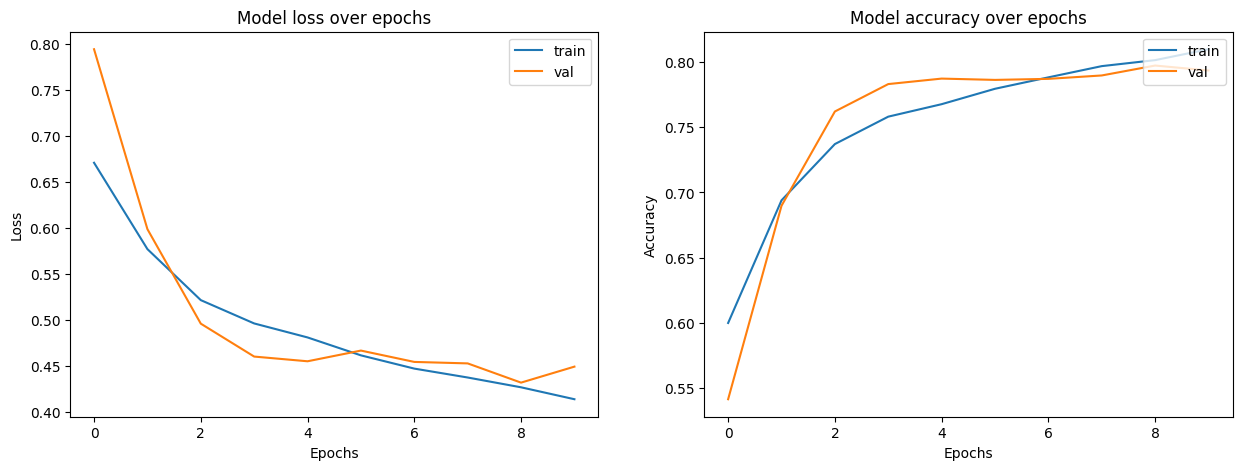

In [ ]:
# Initialize the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot model loss during training
ax1.plot(history.history["loss"])
ax1.plot(history.history["val_loss"])
ax1.legend(["train", "val"], loc="upper right")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Model loss over epochs")

# Plot model accuracy during training
ax2.plot(history.history["accuracy"])
ax2.plot(history.history["val_accuracy"])
ax2.legend(["train", "val"], loc="upper right")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Model accuracy over epochs")
plt.show()

## Predict some movie review samples

In [ ]:
# Make prediction on new text reviews
sample_reviews = [('It is a cool movie. The graphics and the animation are awesome.'),
                  ('The movie was really bad. I would not recommend it to anyone.')]
predictions = model.predict(np.array(sample_reviews))
print(predictions[0])
print(predictions[1])

1/1 [==============================] - 0s 447ms/step
[0.9988203]
[0.00870426]


# PhoBERT

In [1]:
import pandas as pd

In [49]:
# Replace with your actual file path
df = pd.read_csv("/content/review_ecommerce.csv")

In [50]:
df.head(20)

,comment,label,rate,Unnamed: 3
0,Áo bao đẹp ạ!!,POS,5,NaN
1,Tuyệt vời !,POS,5,NaN
2,2day ao khong giong trong.,NEG,1,NaN
3,"Mùi thơm,bôi lên da mềm da.",POS,5,NaN
4,"Vải đẹp, dày dặn.",POS,5,NaN
5,"Hàng rất đẹp, rất chi là ưng ý.",POS,5,NaN
6,"Chất lượng sản phẩm tốt, date dài.",POS,5,NaN
7,Ăn nói và thái độ phục vụ tốt.,POS,4,NaN
8,Đóng gói sản phẩm chắc chắn.,POS,5,NaN
9,tất sờn hết ca chưa dùng mà vay r.,NEG,2,NaN


In [51]:
df.describe()

,rate
count,31460.000000
mean,3.736840
std,1.382483
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [21]:
# Drop the rate and Unnamed collumns
columns_to_drop = ['Unnamed: 3', 'rate']
existing_columns = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=existing_columns, inplace=True)

In [5]:
df.head(5)

,comment,label
0,Áo bao đẹp ạ!!,POS
1,Tuyệt vời !,POS
2,2day ao khong giong trong.,NEG
3,"Mùi thơm,bôi lên da mềm da.",POS
4,"Vải đẹp, dày dặn.",POS


In [24]:
X=df['comment']
y=df['label']

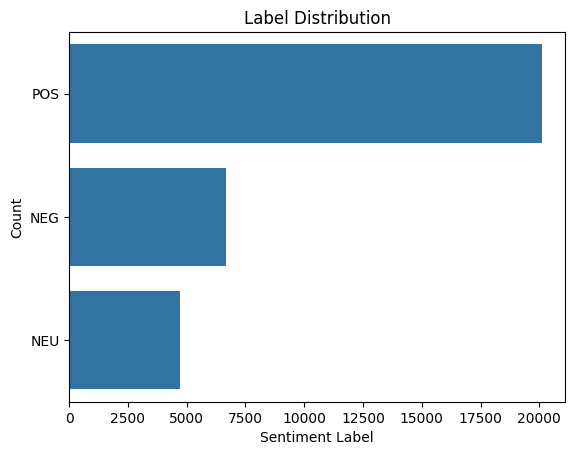

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot using seaborn
sns.countplot(df['label'])
plt.title("Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print("Training set size:", (len(X_train)))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

Training set size: 25168
Validation set size: 3146
Test set size: 3146


In [ ]:
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer

# Load PhoBERT and tokenizer
phobert = TFAutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Inputs
input_ids = tf.keras.Input(shape=(64,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(64,), dtype=tf.int32, name="attention_mask")

bert_outputs = phobert({'input_ids': input_ids, 'attention_mask': attention_mask})
last_hidden_state = bert_outputs.last_hidden_state

# CNN layers
x = tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation="relu")(last_hidden_state)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Output layer for 3 classes
output = tf.keras.layers.Dense(3, activation="softmax")(x)

# Build final model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)


In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),loss=tf.keras.losses.SparseCategoricalCrossentropy(),metrics=["accuracy"])
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, 64)]                 0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 64)]                 0         []                            
                                                                                                  
 tf_roberta_model_1 (TFRobe  TFBaseModelOutputWithPooli   1349982   ['attention_mask[0][0]',      
 rtaModel)                   ngAndCrossAttentions(last_   72         'input_ids[0][0]']           
                             hidden_state=(None, 64, 76                                     

In [27]:
# Map sentiment labels to integers
label_map = {"NEG": 0, "NEU": 1, "POS": 2}
y_train = y_train.map(label_map).astype("int32")
y_val = y_val.map(label_map).astype("int32")
y_test = y_test.map(label_map).astype("int32")


In [28]:
train_encodings = tokenizer(
    list(X_train),
    padding="max_length",
    truncation=True,
    max_length=64,
    return_tensors="tf"
)

val_encodings = tokenizer(
    list(X_val),
    padding="max_length",
    truncation=True,
    max_length=64,
    return_tensors="tf"
)

In [29]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": tf.constant(train_encodings["input_ids"]),
        "attention_mask": tf.constant(train_encodings["attention_mask"])
    },
    tf.constant(y_train)
)).shuffle(1000).batch(64)

val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": tf.constant(val_encodings["input_ids"]),
        "attention_mask": tf.constant(val_encodings["attention_mask"])
    },
    tf.constant(y_val)
)).batch(64)


In [30]:
history = model.fit(train_dataset, epochs=10, batch_size = 64, validation_data=val_dataset)

Epoch 1/10


394/394 [==============================] - 380s 842ms/step - loss: 0.7021 - accuracy: 0.7118 - val_loss: 0.5361 - val_accuracy: 0.7867
Epoch 2/10
394/394 [==============================] - 337s 855ms/step - loss: 0.6362 - accuracy: 0.7422 - val_loss: 0.5295 - val_accuracy: 0.7842
Epoch 3/10
394/394 [==============================] - 328s 832ms/step - loss: 0.5194 - accuracy: 0.7892 - val_loss: 0.4937 - val_accuracy: 0.8010
Epoch 4/10
394/394 [==============================] - 328s 832ms/step - loss: 0.4837 - accuracy: 0.8075 - val_loss: 0.4838 - val_accuracy: 0.7994
Epoch 5/10
394/394 [==============================] - 328s 833ms/step - loss: 0.4594 - accuracy: 0.8144 - val_loss: 0.4866 - val_accuracy: 0.8017
Epoch 6/10
394/394 [==============================] - 325s 824ms/step - loss: 0.4302 - accuracy: 0.8264 - val_loss: 0.4903 - val_accuracy: 0.8004
Epoch 7/10
394/394 [==============================] - 327s 831ms/step - loss: 0.4043 - accuracy: 0.8382 - val_loss: 0.5084 - val_accura

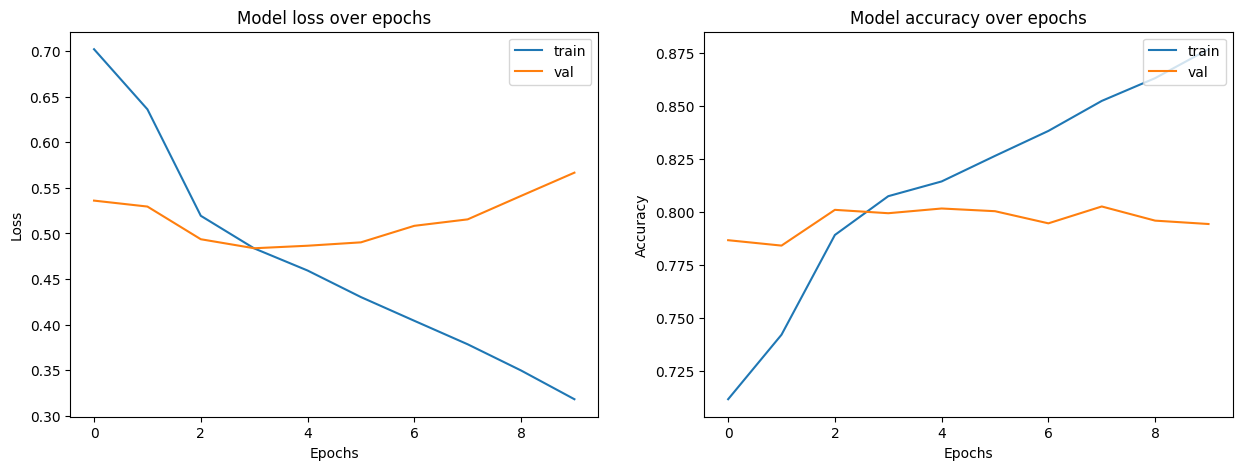

In [31]:
# Initialize the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot model loss during training
ax1.plot(history.history["loss"])
ax1.plot(history.history["val_loss"])
ax1.legend(["train", "val"], loc="upper right")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Model loss over epochs")

# Plot model accuracy during training
ax2.plot(history.history["accuracy"])
ax2.plot(history.history["val_accuracy"])
ax2.legend(["train", "val"], loc="upper right")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Model accuracy over epochs")
plt.show()

In [34]:
test_encodings = tokenizer(list(X_test),padding="max_length",truncation=True,max_length=64,return_tensors="tf")
# Ensure y_test is int32
y_test = y_test.astype("int32")
test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": test_encodings["input_ids"],
        "attention_mask": test_encodings["attention_mask"]
    },
    tf.constant(y_test)
)).batch(16)

In [36]:
results = model.evaluate(test_dataset)
print(f"\nTest Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

197/197 [==============================] - 16s 81ms/step - loss: 0.5411 - accuracy: 0.7988

Test Loss: 0.5411053895950317
Test Accuracy: 0.7987921237945557


In [52]:
# Predict sample review

texts = [
    "Sản phẩm này thật sự gây thất vọng, nhiều lỗi và chậm chạp.",
    "Giao diện khá đẹp nhưng tính năng thì bình thường.",
    "Trải nghiệm tuyệt vời, mọi thứ hoạt động mượt mà!"
]

# Tokenize
inputs = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=64,  #Match model input shape
    return_tensors="tf"
)

# Drop token_type_ids if present (PhoBERT doesn't use them)
if "token_type_ids" in inputs:
    del inputs["token_type_ids"]

# Convert to plain dict
inputs = dict(inputs)

# Predict
logits = model.predict(inputs)
pred_labels = tf.argmax(logits, axis=1).numpy()

# Map predictions
label_map = {0: "NEG", 1: "NEU", 2: "POS"}
for text, label in zip(texts, pred_labels):
    print(f"\"{text}\"\nPrediction: {label_map[label]}\n")

1/1 [==============================] - 0s 85ms/step
"Sản phẩm này thật sự gây thất vọng, nhiều lỗi và chậm chạp."
Prediction: NEG

"Giao diện khá đẹp nhưng tính năng thì bình thường."
Prediction: NEU

"Trải nghiệm tuyệt vời, mọi thứ hoạt động mượt mà!"
Prediction: POS

